In [2]:
# Make sure to run this command in a cell first if you haven't already:
!pip install wfdb

import wfdb
import os

# Define the folder name where you want to store the dataset in Colab
dataset_dir = '/content/mitdb'

# Create the directory if it doesn't exist
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

print("Downloading MIT-BIH Arrhythmia Database. This might take a few minutes...")

# Download the entire database ('mitdb') into the specified Colab directory
wfdb.dl_database('mitdb', dl_dir=dataset_dir)

print("\n--- Download Complete! ---")

# Get and print the absolute path so you can copy/paste it as your path variable
full_path = os.path.abspath(dataset_dir)
print(f"\nYour dataset is ready. Use this as your path variable:")
print(f"mit_bih_path = r\"{full_path}\"")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
Generating record list for: 100
Generating record list for: 1

# **FILE: S26_mitbih_to_csv-final.ipynb**

In [ ]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import signal


def plot_ecg_preview(signal_values, record_name, plot_samples=1000):
    """
    Plot a preview of an ECG waveform using the first plot_samples points.
    """
    # Ensure we never request more points than available in the signal.
    plot_samples = min(int(plot_samples), len(signal_values))
    print(f"Plotting the first {plot_samples} samples for visualization...")

    plt.figure(figsize=(12, 4))
    plt.plot(signal_values[:plot_samples], color='red', linewidth=1.5)
    plt.title(f"Normalized ECG Waveform Preview (Record {record_name}, Lead MLII)")
    plt.xlabel("Sample Number")
    plt.ylabel("Normalized Voltage [0, 1]")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def normalize_recordwise_percentile_minmax(signal_series):
    """
    Offline normalization using full-record percentiles and min-max scaling.
    """
    # Robustly estimate lower/upper bounds from the full record.
    p_low = signal_series.quantile(0.005)
    p_high = signal_series.quantile(0.999)

    # Remove extreme outliers before min-max scaling.
    clipped = signal_series.clip(lower=p_low, upper=p_high)
    min_val = clipped.min()
    max_val = clipped.max()

    # Normalize to [0, 1]; handle flat signals safely.
    if max_val > min_val:
        normalized = (clipped - min_val) / (max_val - min_val)
    else:
        print("Warning: Flat signal after clipping; setting normalized values to 0.0")
        normalized = pd.Series(np.zeros(len(clipped)), index=clipped.index)

    stats = {
        "mode": "record",
        "p_low": float(p_low),
        "p_high": float(p_high),
        "min_val": float(min_val),
        "max_val": float(max_val),
    }
    return normalized, stats


def normalize_online_robust(signal_series, fs, window_sec=10, clip_z=5.0, eps=1e-6):
    """
    Causal/online-like normalization using trailing median and trailing MAD.
    Output is mapped to [0, 1].
    """
    # Convert window duration to number of samples.
    window_samples = max(1, int(window_sec * fs))

    # Estimate baseline from trailing median and remove it.
    baseline = signal_series.rolling(window=window_samples, min_periods=1).median()
    detrended = signal_series - baseline

    # Estimate robust scale using trailing MAD.
    mad = detrended.abs().rolling(window=window_samples, min_periods=1).median()
    robust_scale = 1.4826 * mad  # Converts MAD to sigma-like scale for Gaussian assumptions.
    robust_scale = robust_scale.clip(lower=eps)  # Avoid division by zero.

    # Robust z-score, then clip outliers.
    z = detrended / robust_scale
    z_clipped = z.clip(lower=-clip_z, upper=clip_z)

    # Map clipped z-score from [-clip_z, +clip_z] to [0, 1].
    normalized = (z_clipped + clip_z) / (2 * clip_z)

    stats = {
        "mode": "online",
        "window_sec": float(window_sec),
        "window_samples": int(window_samples),
        "clip_z": float(clip_z),
    }
    return normalized, stats



def convert_and_normalize_mitdb(
    record_name,
    dataset_dir,
    output_filename,
    plot_samples=1000,
    target_fs=125,
    normalization_mode="record",
    online_window_sec=10,
    online_clip_z=5.0,
):
    """
    Reads a local MIT-BIH record, extracts the MLII lead,
    resamples it to target_fs, normalizes it, saves it as a CSV, and plots a preview.

    normalization_mode:
      - "record": full-record percentile clip + min-max (offline)
      - "online": trailing median/MAD robust normalization (causal-like)
    """
    # Validate local dataset path.
    if not dataset_dir:
        raise ValueError("dataset_dir is required and must point to your local MIT-BIH folder")
    if not os.path.isdir(dataset_dir):
        raise FileNotFoundError(f"Local dataset_dir not found: {dataset_dir}")

    # Read the selected record from local WFDB files.
    record_base = os.path.join(dataset_dir, record_name)
    print(f"Loading local record: {record_base}")
    record = wfdb.rdrecord(record_base)

    # Build DataFrame with named leads.
    df = pd.DataFrame(record.p_signal, columns=record.sig_name)

    # Keep only MLII for single-lead pipeline.
    if 'MLII' not in df.columns:
        print(f"Error: 'MLII' lead not found in record {record_name}.")
        print(f"Available leads for this record are: {record.sig_name}")
        return
    df_mlii = df[['MLII']].copy()

    # Resample to target sampling rate.
    original_fs = record.fs
    if original_fs != target_fs:
        print(f"Resampling from {original_fs}Hz to {target_fs}Hz...")
        new_length = int(len(df_mlii) * target_fs / original_fs)
        resampled_signal = signal.resample(df_mlii['MLII'], new_length)
        df_mlii = pd.DataFrame({'MLII': resampled_signal})

        # Keep plot duration approximately equivalent in seconds.
        plot_samples = int(plot_samples * target_fs / original_fs)

    # Select normalization strategy.
    if normalization_mode == "record":
        normalized, norm_stats = normalize_recordwise_percentile_minmax(df_mlii['MLII'])
    elif normalization_mode == "online":
        normalized, norm_stats = normalize_online_robust(
            df_mlii['MLII'],
            fs=target_fs,
            window_sec=online_window_sec,
            clip_z=online_clip_z,
        )
    else:
        raise ValueError("normalization_mode must be 'record' or 'online'")

    # Replace MLII column with normalized values and save.
    df_mlii['MLII'] = normalized
    df_mlii.to_csv(output_filename, index=False)

    # Print normalization summary.
    print(f"Successfully saved normalized MLII from {record_name} to {output_filename}!")
    print(f"Normalization mode: {norm_stats['mode']}")
    if norm_stats['mode'] == 'record':
        print(f"Clip Range (mV): [{norm_stats['p_low']:.3f}, {norm_stats['p_high']:.3f}]")
    else:
        print(f"Online window: {norm_stats['window_sec']} sec ({norm_stats['window_samples']} samples)")
        print(f"Online clip z: ±{norm_stats['clip_z']}")
    print(f"Output Range: [{df_mlii['MLII'].min():.3f}, {df_mlii['MLII'].max():.3f}]")

    # Visual sanity check.
    plot_ecg_preview(df_mlii['MLII'].to_numpy(), record_name=record_name, plot_samples=plot_samples)


def find_and_extract_mixed_snippets(output_dir="mixed_snippets", snippet_duration_min=2, target_fs=125):
    """
    Searches the MIT-BIH database for ~2-minute snippets containing a mix of different
    heartbeat classes, resamples to target_fs, normalizes the MLII lead, and saves them to CSV.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print(f"Searching for {snippet_duration_min}-minute snippets with diverse heartbeats...")

    fs = 360 # Standard sampling frequency for MIT-BIH
    snippet_samples = snippet_duration_min * 60 * fs

    # A curated list of records from MIT-BIH known to contain various arrhythmias
    # 109 = LBBB, 118 = RBBB, 119 = PVCs, 200 = Ventricular bigeminy, etc.
    records_to_check = ['100', '109', '111', '118', '119', '200', '207', '212', '213', '214', '232']

    # Mapping standard MIT-BIH annotation symbols to your project's beat-level classes:
    # 'N': Normal
    # 'L': LBBB
    # 'R': RBBB
    # 'V': PVC
    # 'A': Atrial premature beat (used here as 'Abnormal')

    target_symbols = {'N', 'L', 'R', 'V', 'A'}

    # Keep track of which classes we've successfully found a snippet for
    classes_found = set()
    snippet_count = 0

    for record_name in records_to_check:
        # Stop if we've found all possible beat-level targets
        if target_symbols.issubset(classes_found):
            break

        try:
            # Read annotations and signal directly from PhysioNet
            ann = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')
            record = wfdb.rdrecord(record_name, pn_dir='mitdb')
        except Exception as e:
            print(f"Could not load record {record_name}: {e}")
            continue

        # Create a Pandas DataFrame for the signal
        df = pd.DataFrame(record.p_signal, columns=record.sig_name)
        if 'MLII' not in df.columns:
            continue

        total_samples = record.sig_len

        # Slide a window across the record to find interesting snippets
        for start_idx in range(0, total_samples - snippet_samples, snippet_samples):
            end_idx = start_idx + snippet_samples

            # Find annotations that fall exactly within this 2-minute window
            window_mask = (ann.sample >= start_idx) & (ann.sample < end_idx)
            window_symbols = set(np.array(ann.symbol)[window_mask])

            # Check which of our target symbols are present in this window
            present_targets = window_symbols.intersection(target_symbols)

            # Identify if this snippet contains any classes we haven't found yet
            new_classes_found = present_targets - classes_found

            # If this snippet has a good mix (at least 2 types) AND brings us a new class
            if len(present_targets) >= 2 and len(new_classes_found) > 0:
                classes_found.update(present_targets)
                snippet_count += 1

                # Extract the MLII signal for this specific timeframe
                df_snippet = df[['MLII']].iloc[start_idx:end_idx].copy()

                # Resample the signal down to target_fs
                if fs != target_fs:
                    new_length = int(len(df_snippet) * target_fs / fs)
                    resampled_signal = signal.resample(df_snippet['MLII'], new_length)
                    df_snippet = pd.DataFrame({'MLII': resampled_signal})

                # Normalize using percentile clipping (0.5% and 99.5%) to ignore static/noise spikes
                p_low = df_snippet['MLII'].quantile(0.005)
                p_high = df_snippet['MLII'].quantile(0.995)
                df_snippet['MLII'] = df_snippet['MLII'].clip(lower=p_low, upper=p_high)

                min_val = df_snippet['MLII'].min()
                max_val = df_snippet['MLII'].max()

                if max_val > min_val: # Safety check to avoid division by zero
                    df_snippet['MLII'] = (df_snippet['MLII'] - min_val) / (max_val - min_val)

                # Format the filename based on the beat types found
                classes_str = "_".join(sorted(list(present_targets)))
                minute_mark = start_idx // (60 * fs)
                output_filename = os.path.join(output_dir, f"rec_{record_name}_min_{minute_mark}_{classes_str}.csv")

                # Save to CSV
                df_snippet.to_csv(output_filename, index=False)

                # Calculate and format the timestamps (MM:SS)
                start_time_sec = start_idx / fs
                end_time_sec = end_idx / fs
                start_m, start_s = divmod(int(start_time_sec), 60)
                end_m, end_s = divmod(int(end_time_sec), 60)

                print(f"Saved Snippet {snippet_count}: {output_filename}")
                print(f"  -> Timeframe: {start_m:02d}:{start_s:02d} to {end_m:02d}:{end_s:02d}")
                print(f"  -> Contained target beats: {present_targets}")

                # Break to move to the next record so our snippets are diverse across patients
                break

    print(f"\nFinished extraction!")
    print(f"Successfully captured snippets containing these target beat classes: {classes_found}")


# Example usage 1: Convert a single entire record (30 mins)
# local_dataset_dir = r"C:\datasets\mit-bih-arrhythmia-database-1.0.0"
# target_record = '100'
# output_file_record_mode = 'record_100_mlii_norm_record.csv'
# output_file_online_mode = 'record_100_mlii_norm_online.csv'
# convert_and_normalize_mitdb(target_record, local_dataset_dir, output_file_record_mode, normalization_mode='record')
# convert_and_normalize_mitdb(target_record, local_dataset_dir, output_file_online_mode, normalization_mode='online', online_window_sec=10, online_clip_z=5.0)

# Example usage 2: Hunt for 2-minute snippets with varied heartbeats
#find_and_extract_mixed_snippets(output_dir="mixed_ecg_snippets", snippet_duration_min=2)

In [4]:
import os
import wfdb
import pandas as pd
import numpy as np

# Annotation pipeline for all MIT-BIH records (sample-aligned to 125 Hz)
# Local dataset path is required (no download mode).

CLASS_MAP = {
    'N': 'N',  # Normal beat
    'L': 'L',  # Left bundle branch block beat
    'R': 'R',  # Right bundle branch block beat
    'V': 'V',  # Premature ventricular contraction
    'F': 'F',  # Fusion of ventricular and normal beat
    '/': '/',  # Paced beat
    'A': 'A',  # Atrial premature beat
}


def map_symbol(symbol: str) -> str:
    return CLASS_MAP.get(symbol, 'OTHER')


def _safe_attr_list(obj, attr_name, length, default_value):
    """Helper to extract optional WFDB fields."""
    values = getattr(obj, attr_name, None)
    if values is None:
        return [default_value] * length

    values = list(values)
    if len(values) < length:
        values.extend([default_value] * (length - len(values)))
    elif len(values) > length:
        values = values[:length]
    return values


def _validate_local_dataset_dir(dataset_dir):
    if not dataset_dir:
        raise ValueError("dataset_dir is required and must point to your local MIT-BIH folder")
    if not os.path.isdir(dataset_dir):
        raise FileNotFoundError(f"Local dataset_dir not found: {dataset_dir}")


def _list_local_records(dataset_dir):
    dat_files = [f for f in os.listdir(dataset_dir) if f.lower().endswith('.dat')]
    records = sorted({os.path.splitext(f)[0] for f in dat_files})
    if not records:
        raise FileNotFoundError(f"No .dat files found in local dataset_dir: {dataset_dir}")
    return records


def _read_record_and_ann_local(record_name, dataset_dir):
    record_base = os.path.join(dataset_dir, record_name)
    record = wfdb.rdrecord(record_base)
    ann = wfdb.rdann(record_base, "atr")
    return record, ann


def build_annotations_for_record(
    record_name,
    dataset_dir,
    out_dir="dataset_125hz/annotations",
    target_fs=125,
):
    _validate_local_dataset_dir(dataset_dir)
    record, ann = _read_record_and_ann_local(record_name, dataset_dir)

    original_fs = float(record.fs)
    ratio = target_fs / original_fs
    signal_len_original = int(record.sig_len)
    signal_len_target = int(np.rint(signal_len_original * ratio))

    ann_original = np.asarray(ann.sample, dtype=np.int64)
    ann_target = np.rint(ann_original * ratio).astype(np.int64)
    ann_target = np.clip(ann_target, 0, max(signal_len_target - 1, 0))

    symbols = list(ann.symbol)
    rhythm = _safe_attr_list(ann, "aux_note", len(symbols), "")

    # Map symbols to classes: '+' becomes 'RHYTHM', others map normally
    mapped_classes = [
        'RHYTHM' if s == '+' else map_symbol(s)
        for s in symbols
    ]

    df_ann = pd.DataFrame({
        "record_id": record_name,
        "sample_original": ann_original,
        "sample_125": ann_target,
        "time_sec_original": ann_original / original_fs,
        "time_sec_125": ann_target / target_fs,
        "symbol": symbols,
        "mapped_class": mapped_classes,
        "rhythm": rhythm,
    })

    df_ann = df_ann.sort_values(["sample_125", "sample_original"]).reset_index(drop=True)

    os.makedirs(out_dir, exist_ok=True)
    output_file = os.path.join(out_dir, f"{record_name}_annotations_125hz.csv")
    df_ann.to_csv(output_file, index=False)

    return {
        "record_id": record_name,
        "fs_original": original_fs,
        "fs_target": target_fs,
        "signal_len_original": signal_len_original,
        "signal_len_target": signal_len_target,
        "n_annotations": int(len(df_ann)),
        "n_target_classes": int((df_ann["mapped_class"] != "OTHER").sum()),
        "output_file": output_file,
    }


def build_all_mitbih_annotations(
    dataset_dir,
    out_root="dataset_125hz",
    target_fs=125,
):
    _validate_local_dataset_dir(dataset_dir)

    ann_dir = os.path.join(out_root, "annotations")
    os.makedirs(ann_dir, exist_ok=True)

    records = _list_local_records(dataset_dir)

    summaries = []
    failed = []

    print(f"Found {len(records)} local records in: {dataset_dir}")
    print(f"Building annotation tables at {target_fs} Hz...")

    for i, record_name in enumerate(records, start=1):
        try:
            summary = build_annotations_for_record(
                record_name=record_name,
                dataset_dir=dataset_dir,
                out_dir=ann_dir,
                target_fs=target_fs,
            )
            summaries.append(summary)
            print(f"[{i:02d}/{len(records)}] OK  {record_name} -> {summary['n_annotations']} annotations")
        except Exception as e:
            failed.append({"record_id": record_name, "error": str(e)})
            print(f"[{i:02d}/{len(records)}] FAIL {record_name} -> {e}")

    manifest_df = pd.DataFrame(summaries).sort_values("record_id") if summaries else pd.DataFrame()
    manifest_path = os.path.join(out_root, "annotations_manifest.csv")
    manifest_df.to_csv(manifest_path, index=False)

    failed_df = pd.DataFrame(failed)
    failed_path = os.path.join(out_root, "annotations_failed.csv")
    failed_df.to_csv(failed_path, index=False)

    print("\nDone.")
    print(f"Saved manifest: {manifest_path}")
    print(f"Saved failures: {failed_path}")
    print(f"Success: {len(summaries)} | Failed: {len(failed)}")

    return manifest_df, failed_df

## Annotation strategy (agreed)

- Primary storage is **125 Hz** for both signals and annotations.
- Each record keeps its own continuous timeline (`sample_125`) for streaming-style R-peak workflows.
- Keep both `symbol` (raw MIT-BIH) and `mapped_class` in annotation files.
- Your current mapping is: `N, L, R, V, F, /, A`; everything else becomes `OTHER`.
- Yes: you can still remap `mapped_class` later during preprocessing without losing the original annotation symbol.

In [5]:
# Local MIT-BIH folder path (already downloaded)
# mit_bih_path = r"C:\datasets\mit-bih-arrhythmia-database-1.0.0"     # CINDY: CHANGE THIS!!!
mit_bih_path = r"/content/mitdb"

# Output root for annotations + manifest
# annotations_path = r"C:\repos\ecg-dataset-single-lead\mit-bih"      # CINDY: CHANGE THIS!!!
annotations_path = r"/content/mit-bih"

# Target sampling rate
target_fs = 125

ann_manifest_df, ann_failed_df = build_all_mitbih_annotations(
    dataset_dir=mit_bih_path,
    out_root=annotations_path,
    target_fs=target_fs,
)

ann_manifest_df.head()

Found 48 local records in: /content/mitdb
Building annotation tables at 125 Hz...
[01/48] OK  100 -> 2274 annotations
[02/48] OK  101 -> 1874 annotations
[03/48] OK  102 -> 2192 annotations
[04/48] OK  103 -> 2091 annotations
[05/48] OK  104 -> 2311 annotations
[06/48] OK  105 -> 2691 annotations
[07/48] OK  106 -> 2098 annotations
[08/48] OK  107 -> 2140 annotations
[09/48] OK  108 -> 1824 annotations
[10/48] OK  109 -> 2535 annotations
[11/48] OK  111 -> 2133 annotations
[12/48] OK  112 -> 2550 annotations
[13/48] OK  113 -> 1796 annotations
[14/48] OK  114 -> 1890 annotations
[15/48] OK  115 -> 1962 annotations
[16/48] OK  116 -> 2421 annotations
[17/48] OK  117 -> 1539 annotations
[18/48] OK  118 -> 2301 annotations
[19/48] OK  119 -> 2094 annotations
[20/48] OK  121 -> 1876 annotations
[21/48] OK  122 -> 2479 annotations
[22/48] OK  123 -> 1519 annotations
[23/48] OK  124 -> 1634 annotations
[24/48] OK  200 -> 2792 annotations
[25/48] OK  201 -> 2039 annotations
[26/48] OK  202 ->

,record_id,fs_original,fs_target,signal_len_original,signal_len_target,n_annotations,n_target_classes,output_file
0,100,360.0,125,650000,225694,2274,2274,/content/mit-bih/annotations/100_annotations_1...
1,101,360.0,125,650000,225694,1874,1864,/content/mit-bih/annotations/101_annotations_1...
2,102,360.0,125,650000,225694,2192,2136,/content/mit-bih/annotations/102_annotations_1...
3,103,360.0,125,650000,225694,2091,2085,/content/mit-bih/annotations/103_annotations_1...
4,104,360.0,125,650000,225694,2311,1590,/content/mit-bih/annotations/104_annotations_1...


In [6]:
# Convert all local MIT-BIH records to MLII-only CSV files at 125 Hz
# and save BOTH normalization variants under: <annotations_path>/signals

local_dataset_dir = mit_bih_path
signals_root = os.path.join(annotations_path, "signals")
record_norm_dir = os.path.join(signals_root, "record_minmax")
online_norm_dir = os.path.join(signals_root, "online_robust")

os.makedirs(record_norm_dir, exist_ok=True)
os.makedirs(online_norm_dir, exist_ok=True)

# Discover all records from local MIT-BIH folder
record_ids = sorted({os.path.splitext(f)[0] for f in os.listdir(local_dataset_dir) if f.lower().endswith('.dat')})
print(f"Found {len(record_ids)} records in local dataset folder.")

# Disable plotting for batch processing
_original_plot_ecg_preview = plot_ecg_preview
plot_ecg_preview = lambda *args, **kwargs: None

summary_rows = []
failed_rows = []

for i, record_id in enumerate(record_ids, start=1):
    try:
        record_out = os.path.join(record_norm_dir, f"{record_id}_mlii_125hz_record.csv")
        online_out = os.path.join(online_norm_dir, f"{record_id}_mlii_125hz_online.csv")

        convert_and_normalize_mitdb(
            record_name=record_id,
            dataset_dir=local_dataset_dir,
            output_filename=record_out,
            target_fs=125,
            normalization_mode="record",
        )

        convert_and_normalize_mitdb(
            record_name=record_id,
            dataset_dir=local_dataset_dir,
            output_filename=online_out,
            target_fs=125,
            normalization_mode="online",
            online_window_sec=10,
            online_clip_z=5.0,
        )

        summary_rows.append({
            "record_id": record_id,
            "record_csv": record_out,
            "online_csv": online_out,
            "status": "ok",
        })
        print(f"[{i:02d}/{len(record_ids)}] OK  {record_id}")

    except Exception as e:
        failed_rows.append({
            "record_id": record_id,
            "error": str(e),
        })
        print(f"[{i:02d}/{len(record_ids)}] FAIL {record_id}: {e}")

# Restore plotting function
plot_ecg_preview = _original_plot_ecg_preview

signals_manifest_df = pd.DataFrame(summary_rows)
signals_failed_df = pd.DataFrame(failed_rows)

signals_manifest_path = os.path.join(signals_root, "signals_manifest.csv")
signals_failed_path = os.path.join(signals_root, "signals_failed.csv")

signals_manifest_df.to_csv(signals_manifest_path, index=False)
signals_failed_df.to_csv(signals_failed_path, index=False)

print("\nDone.")
print(f"Signals root: {signals_root}")
print(f"Manifest:     {signals_manifest_path}")
print(f"Failures:     {signals_failed_path}")
print(f"Success: {len(signals_manifest_df)} | Failed: {len(signals_failed_df)}")

signals_manifest_df.head()

Found 48 records in local dataset folder.
Loading local record: /content/mitdb/100
Resampling from 360Hz to 125Hz...
Successfully saved normalized MLII from 100 to /content/mit-bih/signals/record_minmax/100_mlii_125hz_record.csv!
Normalization mode: record
Clip Range (mV): [-0.573, 1.154]
Output Range: [0.000, 1.000]
Loading local record: /content/mitdb/100
Resampling from 360Hz to 125Hz...
Successfully saved normalized MLII from 100 to /content/mit-bih/signals/online_robust/100_mlii_125hz_online.csv!
Normalization mode: online
Online window: 10.0 sec (1250 samples)
Online clip z: ±5.0
Output Range: [0.000, 1.000]
[01/48] OK  100
Loading local record: /content/mitdb/101
Resampling from 360Hz to 125Hz...
Successfully saved normalized MLII from 101 to /content/mit-bih/signals/record_minmax/101_mlii_125hz_record.csv!
Normalization mode: record
Clip Range (mV): [-0.752, 1.501]
Output Range: [0.000, 1.000]
Loading local record: /content/mitdb/101
Resampling from 360Hz to 125Hz...
Successful

,record_id,record_csv,online_csv,status
0,100,/content/mit-bih/signals/record_minmax/100_mli...,/content/mit-bih/signals/online_robust/100_mli...,ok
1,101,/content/mit-bih/signals/record_minmax/101_mli...,/content/mit-bih/signals/online_robust/101_mli...,ok
2,102,/content/mit-bih/signals/record_minmax/102_mli...,/content/mit-bih/signals/online_robust/102_mli...,ok
3,103,/content/mit-bih/signals/record_minmax/103_mli...,/content/mit-bih/signals/online_robust/103_mli...,ok
4,104,/content/mit-bih/signals/record_minmax/104_mli...,/content/mit-bih/signals/online_robust/104_mli...,ok


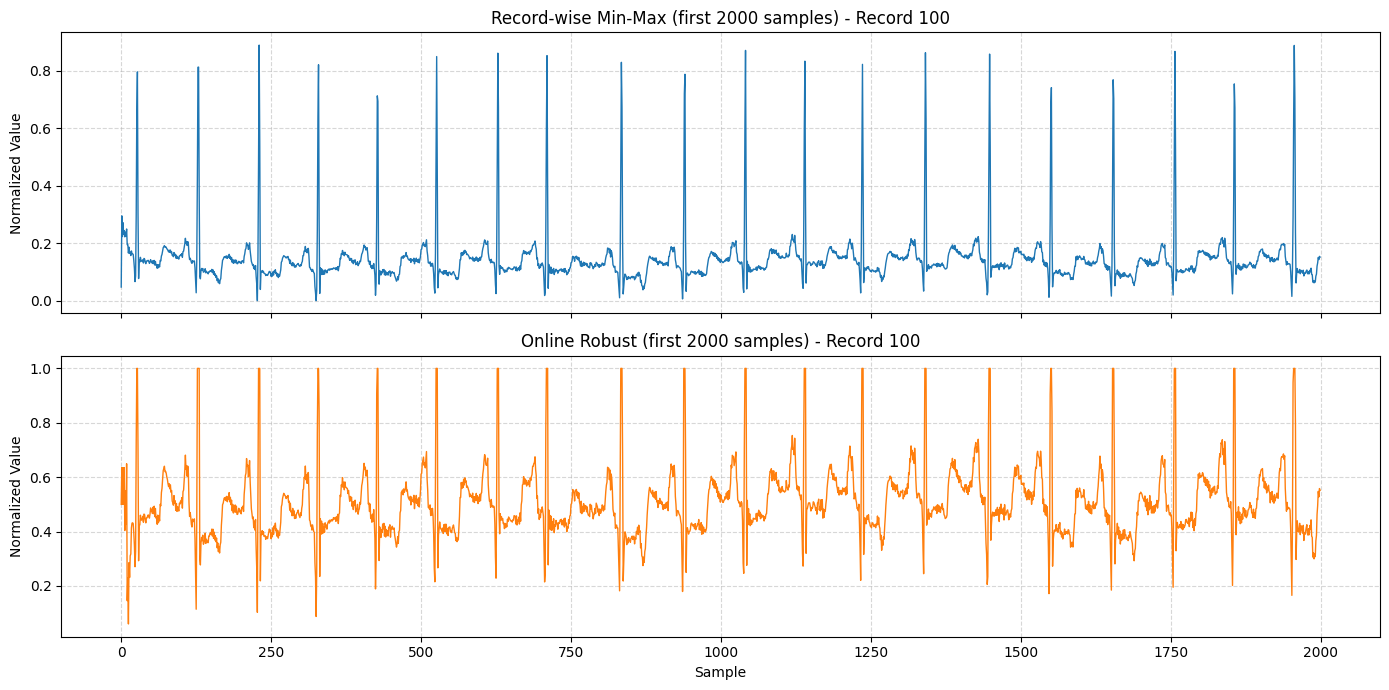

,mode,min,max,mean,std,q01,q99
0,record_minmax,0.0,1.0,0.154376,0.111210,0.015662,0.805674
1,online_robust,0.0,1.0,0.512291,0.130499,0.254117,1.000000


In [7]:
# Compare record-wise vs online normalization for one record (visual + quick stats)

# Pick a record to compare (change if needed)
compare_record_id = "100"

record_csv = os.path.join(signals_root, "record_minmax", f"{compare_record_id}_mlii_125hz_record.csv")
online_csv = os.path.join(signals_root, "online_robust", f"{compare_record_id}_mlii_125hz_online.csv")

if not os.path.exists(record_csv):
    raise FileNotFoundError(f"Record-normalized CSV not found: {record_csv}")
if not os.path.exists(online_csv):
    raise FileNotFoundError(f"Online-normalized CSV not found: {online_csv}")

df_record = pd.read_csv(record_csv)
df_online = pd.read_csv(online_csv)

n = min(len(df_record), len(df_online))
plot_samples = min(2000, n)

record_signal = df_record["MLII"].iloc[:plot_samples].to_numpy()
online_signal = df_online["MLII"].iloc[:plot_samples].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(record_signal, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"Record-wise Min-Max (first {plot_samples} samples) - Record {compare_record_id}")
axes[0].set_ylabel("Normalized Value")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(online_signal, color="tab:orange", linewidth=1.0)
axes[1].set_title(f"Online Robust (first {plot_samples} samples) - Record {compare_record_id}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Normalized Value")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

stats_compare = pd.DataFrame([
    {
        "mode": "record_minmax",
        "min": float(df_record["MLII"].min()),
        "max": float(df_record["MLII"].max()),
        "mean": float(df_record["MLII"].mean()),
        "std": float(df_record["MLII"].std()),
        "q01": float(df_record["MLII"].quantile(0.01)),
        "q99": float(df_record["MLII"].quantile(0.99)),
    },
    {
        "mode": "online_robust",
        "min": float(df_online["MLII"].min()),
        "max": float(df_online["MLII"].max()),
        "mean": float(df_online["MLII"].mean()),
        "std": float(df_online["MLII"].std()),
        "q01": float(df_online["MLII"].quantile(0.01)),
        "q99": float(df_online["MLII"].quantile(0.99)),
    },
])

stats_compare

# **FILE: preprocessing_for_rpeak.ipynb**

Filtering

In [8]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import signal


# Local MIT-BIH folder path (already downloaded)
# mit_bih_path = r"C:\datasets\mit-bih-arrhythmia-database-1.0.0"     # CINDY: CHANGE THIS!!!
mit_bih_path = r"/content/mitdb"

# Output root for annotations + manifest
# annotations_path = r"C:\repos\ecg-dataset-single-lead\mit-bih"      # CINDY: CHANGE THIS!!!
annotations_path = r"/content/mit-bih"

# Target sampling rate
target_fs = 125

In [9]:
def init_stateful_bandpass_filter(fs=125, lowcut=0.5, highcut=40.0, order=2):
    """
    Initialize a low-compute causal bandpass filter state (SOS IIR).

    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    if not (0 < low < high < 1):
        raise ValueError("Invalid cutoff frequencies. Need 0 < lowcut < highcut < fs/2")

    sos = signal.butter(order, [low, high], btype="bandpass", output="sos")

    return {
        "fs": int(fs),
        "sos": sos,
        "zi": None,
        "next_sample": None,
        "lowcut": float(lowcut),
        "highcut": float(highcut),
        "order": int(order),
    }


def filter_window_stateful(window_samples, filter_state, window_start_sample=None):
    """
    Causal low-compute filtering for repeated 2-second windows.

    Important:
    - In overlapping mode, this function filters ONLY the new tail (unseen samples)
      to keep filter state correct without caching old outputs.
    - Returned signal is therefore the new filtered segment, not the full window.

    Parameters
    ----------
    window_samples : array-like
        Current window (typically 2 seconds).
    filter_state : dict
        State from init_stateful_bandpass_filter(...), updated in-place.
    window_start_sample : int or None
        Absolute sample index for first sample in this window.

    Returns
    -------
    filtered_new_only : np.ndarray
        Filtered samples that are new in time.
    meta : dict
        overlap/new sample counts and index info.
    """
    x = np.asarray(window_samples, dtype=np.float64)
    if x.ndim != 1:
        x = x.reshape(-1)

    if len(x) == 0:
        return np.array([], dtype=np.float64), {"overlap_samples": 0, "new_samples": 0}

    sos = filter_state["sos"]

    # Initialize filter memory using the first observed sample.
    if filter_state["zi"] is None:
        filter_state["zi"] = signal.sosfilt_zi(sos) * x[0]

    # If no index is provided, assume strictly contiguous chunks (no overlap handling).
    if window_start_sample is None:
        y_new, filter_state["zi"] = signal.sosfilt(sos, x, zi=filter_state["zi"])

        if filter_state["next_sample"] is None:
            start = 0
            filter_state["next_sample"] = len(x)
        else:
            start = filter_state["next_sample"]
            filter_state["next_sample"] += len(x)

        meta = {
            "overlap_samples": 0,
            "new_samples": int(len(y_new)),
            "window_start_sample": int(start),
            "window_end_sample": int(start + len(x) - 1),
        }
        return y_new, meta

    # Indexed mode: support overlap by skipping already-processed prefix.
    window_start_sample = int(window_start_sample)

    if filter_state["next_sample"] is None:
        overlap_len = 0
    else:
        overlap_len = max(0, filter_state["next_sample"] - window_start_sample)
    overlap_len = min(overlap_len, len(x))

    x_new = x[overlap_len:]

    if len(x_new) > 0:
        y_new, filter_state["zi"] = signal.sosfilt(sos, x_new, zi=filter_state["zi"])
    else:
        y_new = np.array([], dtype=np.float64)

    new_start = window_start_sample + overlap_len
    if filter_state["next_sample"] is None:
        filter_state["next_sample"] = new_start + len(y_new)
    else:
        filter_state["next_sample"] = max(filter_state["next_sample"], new_start + len(y_new))

    meta = {
        "overlap_samples": int(overlap_len),
        "new_samples": int(len(y_new)),
        "window_start_sample": int(window_start_sample),
        "window_end_sample": int(window_start_sample + len(x) - 1),
        "new_start_sample": int(new_start) if len(y_new) > 0 else None,
        "new_end_sample": int(new_start + len(y_new) - 1) if len(y_new) > 0 else None,
    }
    return y_new, meta

This cell is just for testing the filter logic with simulated streaming of 1 second overlap

In [ ]:
# # Simulation loop: first local record, 2-second windows with 1-second overlap
# # This emulates repeated calls where each call receives a 2-second window.

# # 1) Pick first record from local MIT-BIH folder
# local_dataset_dir = mit_bih_path
# record_ids_local = sorted({os.path.splitext(f)[0] for f in os.listdir(local_dataset_dir) if f.lower().endswith('.dat')})
# if not record_ids_local:
#     raise FileNotFoundError(f"No .dat records found in: {local_dataset_dir}")

# sim_record_id = record_ids_local[0]
# record = wfdb.rdrecord(os.path.join(local_dataset_dir, sim_record_id))
# df = pd.DataFrame(record.p_signal, columns=record.sig_name)

# if "MLII" not in df.columns:
#     raise ValueError(f"MLII not found in first record {sim_record_id}. Available leads: {record.sig_name}")

# # 2) Resample to 125 Hz to match embedded target pipeline
# x = df["MLII"].to_numpy(dtype=np.float64)
# orig_fs = float(record.fs)
# target_fs = 125
# new_len = int(len(x) * target_fs / orig_fs)
# x_125 = signal.resample(x, new_len)

# # 3) Create stateful filter and stream overlapping windows
# fstate = init_stateful_bandpass_filter(fs=target_fs, lowcut=0.5, highcut=40.0, order=2)

# win_size = 2 * target_fs   # 2 seconds
# hop_size = 1 * target_fs   # 1-second overlap -> hop is 1 second

# filtered_stream_parts = []
# meta_rows = []

# for start_idx in range(0, len(x_125) - win_size + 1, hop_size):
#     window = x_125[start_idx:start_idx + win_size]
#     y_new, meta = filter_window_stateful(window, fstate, window_start_sample=start_idx)

#     filtered_stream_parts.append(y_new)
#     meta_rows.append({
#         "window_start": start_idx,
#         "window_end": start_idx + win_size - 1,
#         "overlap_samples": meta["overlap_samples"],
#         "new_samples": meta["new_samples"],
#     })

# # 4) Reconstruct filtered continuous stream from new-only outputs
# filtered_stream = np.concatenate(filtered_stream_parts) if filtered_stream_parts else np.array([])
# meta_df = pd.DataFrame(meta_rows)

# print(f"Simulation record: {sim_record_id}")
# print(f"Original fs: {orig_fs} Hz -> Target fs: {target_fs} Hz")
# print(f"Windows processed: {len(meta_df)}")
# print(f"Total input samples @125Hz: {len(x_125)}")
# print(f"Total filtered new samples: {len(filtered_stream)}")

# # 5) Quick visual check (first 12 seconds)
# plot_n = min(12 * target_fs, len(filtered_stream))
# plt.figure(figsize=(12, 4))
# plt.plot(filtered_stream[:plot_n], linewidth=1.0, color="tab:green")
# plt.title(f"Stateful causal filtered stream (first {plot_n} samples) - record {sim_record_id}")
# plt.xlabel("Sample @125Hz")
# plt.ylabel("Filtered amplitude")
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

# meta_df.head(10)

## Peak_detector is the function where we will evaluate the detector algorithm. By default it has a peak detector from neurokit.
Cindy, you can add your function here with this name (comment the current one to keep it for comparison), the rest of the logic should work (the function receives a 2 second window and has to output the samples where it detected R-peaks.)

In [11]:
!pip install neurokit2
import neurokit2 as nk

def peak_detector(window_2s, fs=125):
    """
    Library-based detector using NeuroKit2.
    Input: 1D array of length ~250 (2 seconds at 125 Hz)
    Output: list of detected peak indices relative to window start.
    """
    window_2s = np.asarray(window_2s, dtype=np.float64)
    if len(window_2s) == 0:
        return []

    # NeuroKit2 returns a dict with key 'ECG_R_Peaks' (indices in this local window)
    # Method 'neurokit' is a good general default for ECG.
    try:
        _, info = nk.ecg_peaks(window_2s, sampling_rate=fs, method="neurokit", correct_artifacts=False)
        peaks = info.get("ECG_R_Peaks", [])
    except Exception:
        peaks = []

    return [int(p) for p in peaks if 0 <= int(p) < len(window_2s)]


def pan_tompkins_peak_detector(window_2s, fs=125):
    """
    Canonical Pan-Tompkins-style R-peak detector (window-local indices).

    Steps:
      1) Bandpass filter (~5-15 Hz)
      2) Derivative
      3) Squaring
      4) Moving-window integration (~150 ms)
      5) Adaptive threshold peak candidates + refractory
      6) R-peak localization on bandpassed signal

    Returns
    -------
    list[int]
        Peak indices relative to window start.
    """
    x = np.asarray(window_2s, dtype=np.float64).reshape(-1)
    n = len(x)
    if n < max(5, int(0.3 * fs)):
        return []

    # 1) Bandpass filter (Pan-Tompkins-inspired passband).
    low_hz, high_hz = 5.0, 15.0
    nyq = 0.5 * float(fs)
    low = max(1e-4, low_hz / nyq)
    high = min(0.999, high_hz / nyq)
    if not (0 < low < high < 1):
        return []

    try:
        b, a = signal.butter(2, [low, high], btype="bandpass")
        x_bp = signal.lfilter(b, a, x)
    except Exception:
        return []

    # 2) Derivative filter (Pan-Tompkins finite difference approximation).
    d_kernel = np.array([1, 2, 0, -2, -1], dtype=np.float64) / 8.0
    x_d = np.convolve(x_bp, d_kernel, mode="same")

    # 3) Squaring.
    x_sq = x_d * x_d

    # 4) Moving-window integration (~150 ms).
    mwi_len = max(1, int(round(0.150 * fs)))
    mwi_kernel = np.ones(mwi_len, dtype=np.float64) / mwi_len
    x_mwi = np.convolve(x_sq, mwi_kernel, mode="same")

    # 5) Candidate peaks on integrated signal.
    refractory = max(1, int(round(0.200 * fs)))  # 200 ms
    thr = float(np.mean(x_mwi) + 0.5 * np.std(x_mwi))
    if not np.isfinite(thr):
        return []

    cand_peaks, _ = signal.find_peaks(x_mwi, height=thr, distance=refractory)
    if len(cand_peaks) == 0:
        return []

    # 6) Refine each candidate to true R on bandpassed signal.
    search_radius = max(1, int(round(0.120 * fs)))  # ±120 ms
    refined = []

    for p in cand_peaks:
        left = max(0, int(p) - search_radius)
        right = min(n, int(p) + search_radius + 1)
        if right <= left:
            continue

        local = x_bp[left:right]
        if local.size == 0:
            continue

        # R can be positive or negative depending on lead polarity.
        offset = int(np.argmax(np.abs(local)))
        r_idx = left + offset
        refined.append(r_idx)

    if len(refined) == 0:
        return []

    # De-duplicate with refractory constraint on refined peaks.
    refined = sorted(int(r) for r in refined if 0 <= int(r) < n)
    dedup = [refined[0]]
    for r in refined[1:]:
        if (r - dedup[-1]) >= refractory:
            dedup.append(r)
        elif np.abs(x_bp[r]) > np.abs(x_bp[dedup[-1]]):
            dedup[-1] = r

    return dedup


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 36.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.1
    Uninstalling pandas-3.0.1:
      Successfully uninstalled pandas-3.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [12]:
# CINDY: 2 NEW R-PEAK DETECTOR ALGOS

def sma_detector(window_2s, fs=125):
    fast_win_ms = 80
    fast_win_samples = max(1, int(fast_win_ms * 1e-3 * fs))
    slow_win_ms = 200
    slow_win_samples = max(1, int(slow_win_ms * 1e-3 * fs))
    refractory_ms = 200
    refractory_samples = max(1, int(refractory_ms * 1e-3 * fs))

    fast_sum = 0.0
    slow_sum = 0.0

    history_size = slow_win_samples
    history = [0.0] * history_size
    history_index = 0

    was_above = False
    last_detection_index = -refractory_samples
    out_indices = []

    for n in range(len(window_2s)):
        rectified_val = window_2s[n]
        old_val = history[history_index]
        fast_history_idx = (history_index - fast_win_samples + history_size) % history_size
        fast_old_val = history[fast_history_idx]

        fast_sum = fast_sum + rectified_val - fast_old_val
        slow_sum = slow_sum + rectified_val - old_val

        history[history_index] = rectified_val
        history_index = (history_index + 1) % history_size

        if n < history_size:
            continue

        fast_sma = fast_sum / fast_win_samples
        slow_sma = slow_sum / slow_win_samples

        is_above = (fast_sma > slow_sma)

        if is_above and not was_above:
            if (n - last_detection_index) > refractory_samples:
                search_win = fast_win_samples // 2
                search_start = max(0, n - search_win)
                search_end = min(len(window_2s) - 1, n + search_win // 2)

                rpeak_idx = n
                rpeak_val = -1e9

                for i in range(search_start, search_end + 1):
                    if window_2s[i] > rpeak_val:
                        rpeak_val = window_2s[i]
                        rpeak_idx = i

                out_indices.append(rpeak_idx)
                last_detection_index = n
        was_above = is_above

    return out_indices


def hc_detector(window_2s, fs=125):
    mwi_win_ms = 80
    mwi_win_samples = max(1, int(mwi_win_ms * 1e-3 * fs))
    refractory_ms = 200
    refractory_samples = max(1, int(refractory_ms * 1e-3 * fs))

    spk = 0.0
    npk = 0.0
    threshold = 0.0

    mwi_history = [0.0] * mwi_win_samples
    mwi_index = 0
    mwi_sum = 0.0

    out_indices = []
    last_detection_index = -refractory_samples

    if len(window_2s) == 0:
        return []

    x_prev1 = window_2s[0]
    x_prev2 = x_prev1

    for n in range(len(window_2s)):
        x_n = window_2s[n]

        dx = abs(x_n - x_prev1) + abs(x_n - x_prev2)
        x_prev2 = x_prev1
        x_prev1 = x_n

        old_val = mwi_history[mwi_index]
        mwi_sum = mwi_sum + dx - old_val

        mwi_history[mwi_index] = dx
        mwi_index = (mwi_index + 1) % mwi_win_samples

        if n < mwi_win_samples:
            current_mwi = mwi_sum / mwi_win_samples
            if current_mwi > spk:
                spk = current_mwi
            continue

        mwi_val = mwi_sum / mwi_win_samples
        threshold = npk + 0.3125 * (spk - npk)

        if mwi_val > threshold:
            if (n - last_detection_index) > refractory_samples:
                search_win = mwi_win_samples + 2
                search_start = max(0, n - search_win)
                search_end = n

                rpeak_idx = n
                rpeak_val = -1e9

                for i in range(search_start, search_end + 1):
                    if window_2s[i] > rpeak_val:
                        rpeak_val = window_2s[i]
                        rpeak_idx = i

                out_indices.append(rpeak_idx)
                last_detection_index = n
                spk = 0.125 * mwi_val + 0.875 * spk
        else:
            if (n - last_detection_index) > refractory_samples:
                npk = 0.125 * mwi_val + 0.875 * npk

    return out_indices

In [13]:
# R-peak detector evaluation framework (stream-style, 2-second windows)


def list_local_record_ids(local_dataset_dir):
    """Return sorted MIT-BIH record IDs from a local dataset directory."""
    record_ids = sorted({
        os.path.splitext(f)[0]
        for f in os.listdir(local_dataset_dir)
        if f.lower().endswith('.dat')
    })
    if not record_ids:
        raise FileNotFoundError(f"No .dat records found in: {local_dataset_dir}")
    return record_ids


def load_record_and_ground_truth(record_id, annotations_root, signal_mode="online_robust"):
    """
    Load one record by ID, then load:
      - precomputed 125 Hz signal from signals/<mode>/
      - GT R-peak samples from annotations CSV

    signal_mode options:
      - "online_robust"
      - "record_minmax"
    """
    # Resolve signal mode.
    mode_map = {
        "online_robust": "online_robust",
        "record_minmax": "record_minmax",
    }
    if signal_mode not in mode_map:
        raise ValueError("signal_mode must be 'online_robust' or 'record_minmax'")

    resolved_mode = mode_map[signal_mode]
    record_id = str(record_id)

    # Load precomputed 125 Hz signal from signals folder.
    signal_csv = os.path.join(
        annotations_root,
        "signals",
        resolved_mode,
        f"{record_id}_mlii_125hz_{'online' if resolved_mode == 'online_robust' else 'record'}.csv",
    )
    if not os.path.exists(signal_csv):
        raise FileNotFoundError(
            f"125 Hz signal CSV not found for record '{record_id}' mode '{resolved_mode}': {signal_csv}"
        )

    signal_df = pd.read_csv(signal_csv)
    if "MLII" not in signal_df.columns:
        raise ValueError(f"Signal CSV must contain 'MLII' column: {signal_csv}")

    x_125 = signal_df["MLII"].to_numpy(dtype=np.float64)

    # Load annotations (already aligned to 125 Hz)
    ann_csv = os.path.join(annotations_root, "annotations", f"{record_id}_annotations_125hz.csv")
    if not os.path.exists(ann_csv):
        raise FileNotFoundError(f"Annotation CSV not found: {ann_csv}")

    ann_df = pd.read_csv(ann_csv)

    # Keep beat-like annotations only (exclude rhythm marker '+').
    if "symbol" not in ann_df.columns or "sample_125" not in ann_df.columns:
        raise ValueError("Annotation CSV must contain 'symbol' and 'sample_125' columns")

    gt_samples = np.sort(ann_df.loc[ann_df["symbol"] != "+", "sample_125"].astype(int).to_numpy())

    return record_id, x_125, gt_samples, ann_df, signal_csv


def evaluate_rpeak_detector_stream(
    signal_1d,
    gt_samples,
    detector_fn,
    fs=125,
    window_sec=2,
    tolerance_ms=150,
    initial_prev_peak=None,
    apply_causal_filter=False,
    causal_filter_config=None,
    anchor_offset_samples=20,
):
    """
    Emulates embedded detector behavior:
      1) First window starts at sample 0 (length = window_sec * fs).
      2) After detecting an R-peak at sample r_k, next window starts at (r_k - anchor_offset_samples).
      3) For subsequent windows, ignore the first detected peak (expected carry-over near index ~anchor_offset_samples),
         and evaluate ONLY the second detected peak.
      4) Exception: for the very first beat, evaluate the first detected peak.

    detector_fn(window) or detector_fn(window, fs=...) returns relative peak positions.
    We translate the selected peak to absolute samples and match against GT within ±tolerance.

    Optional: apply a causal stateful bandpass filter before detector_fn.
    """
    signal_1d = np.asarray(signal_1d, dtype=np.float64)
    gt_samples = np.sort(np.asarray(gt_samples, dtype=int))

    window_size = int(window_sec * fs)
    tolerance = int(round((tolerance_ms / 1000.0) * fs))
    anchor_offset_samples = int(anchor_offset_samples)

    if window_size <= 0:
        raise ValueError("window_sec * fs must be > 0")
    if anchor_offset_samples < 0:
        raise ValueError("anchor_offset_samples must be >= 0")

    # If initial_prev_peak is provided, we already have a prior beat anchor;
    # then the next evaluated peak should be the second one in the window.
    if initial_prev_peak is None:
        prev_detected_peak = None
        first_beat_pending = True
    else:
        prev_detected_peak = int(initial_prev_peak)
        first_beat_pending = False

    # Optional causal filter setup.
    filter_state = None
    if apply_causal_filter:
        cfg = causal_filter_config or {}
        filter_state = init_stateful_bandpass_filter(
            fs=fs,
            lowcut=float(cfg.get("lowcut", 0.5)),
            highcut=float(cfg.get("highcut", 40.0)),
            order=int(cfg.get("order", 2)),
        )

    gt_matched = np.zeros(len(gt_samples), dtype=bool)
    events = []

    while True:
        # Embedded-style window placement.
        if prev_detected_peak is None:
            window_start = 0
        else:
            window_start = int(prev_detected_peak) - anchor_offset_samples

        if window_start < 0:
            window_start = 0
        window_end = window_start + window_size

        if window_end > len(signal_1d):
            break

        window_raw = signal_1d[window_start:window_end]

        # Optional causal filtering before detector call.
        if apply_causal_filter:
            detector_input, filter_meta = filter_window_stateful(
                window_raw,
                filter_state,
                window_start_sample=window_start,
            )
            detector_base_sample = (
                int(filter_meta["new_start_sample"])
                if filter_meta.get("new_start_sample") is not None
                else int(window_start)
)
        else:
            detector_input = window_raw
            detector_base_sample = int(window_start)

        # Support detectors with either signature: fn(window) or fn(window, fs=...).
        try:
            rel_peaks = detector_fn(detector_input, fs=fs)
        except TypeError:
            rel_peaks = detector_fn(detector_input)

        current_len = len(detector_input)
        rel_peaks = sorted([int(p) for p in rel_peaks if 0 <= int(p) < current_len])

        # Select evaluated peak according to embedded rule.
        evaluated_peak_rank = None
        selected_rel_peak = None

        if first_beat_pending:
            if len(rel_peaks) >= 1:
                selected_rel_peak = rel_peaks[0]
                evaluated_peak_rank = 1
        else:
            if len(rel_peaks) >= 2:
                selected_rel_peak = rel_peaks[1]
                evaluated_peak_rank = 2

        if selected_rel_peak is not None:
            detected_abs = detector_base_sample + selected_rel_peak

            # Match to nearest unmatched GT within tolerance.
            unmatched_idx = np.where(~gt_matched)[0]
            matched_gt = None
            error_samples = None
            is_correct = False

            if len(unmatched_idx) > 0:
                candidate_gt = gt_samples[unmatched_idx]
                diffs = np.abs(candidate_gt - detected_abs)
                within_tol = np.where(diffs <= tolerance)[0]

                if len(within_tol) > 0:
                    best_local = within_tol[np.argmin(diffs[within_tol])]
                    best_idx = unmatched_idx[best_local]
                    gt_matched[best_idx] = True
                    matched_gt = int(gt_samples[best_idx])
                    error_samples = int(detected_abs - matched_gt)
                    is_correct = True

            events.append({
                "window_start": int(window_start),
                "window_end": int(window_end - 1),
                "detected_abs": int(detected_abs),
                "matched_gt": matched_gt,
                "error_samples": error_samples,
                "is_correct": bool(is_correct),
                "n_detected_in_window": int(len(rel_peaks)),
                "evaluated_peak_rank": evaluated_peak_rank,
            })

            # This selected beat becomes anchor for next window.
            prev_detected_peak = int(detected_abs)
            first_beat_pending = False

        else:
            # No evaluable peak in this window (e.g., no peaks, or only 1 peak in non-first window).
            events.append({
                "window_start": int(window_start),
                "window_end": int(window_end - 1),
                "detected_abs": None,
                "matched_gt": None,
                "error_samples": None,
                "is_correct": False,
                "n_detected_in_window": int(len(rel_peaks)),
                "evaluated_peak_rank": None,
            })

            # Advance safely in time to avoid stalling.
            prev_detected_peak = int(window_start + window_size)

    events_df = pd.DataFrame(events)

    tp = int(events_df["is_correct"].sum())
    fp = int(events_df["detected_abs"].notna().sum() - tp)
    fn = int((~gt_matched).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    detection_error_rate = (fp + fn) / (tp + fn) if (tp + fn) > 0 else 0.0

    summary = {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision / ppv": precision,
        "recall / sensitivity": recall,
        "f1": f1,
        "detection_error_rate": detection_error_rate,
        "tolerance_samples": tolerance,
        "tolerance_ms": tolerance_ms,
        "windows_processed": int(len(events_df)),
        "apply_causal_filter": bool(apply_causal_filter),
        "anchor_offset_samples": int(anchor_offset_samples),
    }

    return events_df, summary


In [27]:
# -------- Run evaluation on first record --------
# Choose which precomputed 125 Hz signal set to evaluate:
#   - "online_robust"  #Uses a causal normalization (appropriate for online use)
#   - "record_minmax"  #It uses a per-record normalization (peeks into the future)
signal_mode_eval = "record_minmax"

# Choose detector function to evaluate:
#   - peak_detector (NeuroKit2)
#   - pan_tompkins_peak_detector (canonical Pan-Tompkins-style)
### CINDY: NEW ALGOS
#   - sma_detector (Two Moving Averages)
#   - hc_detector (Hamilton & Christov)
detector_fn_eval = peak_detector

# Toggle causal pre-filter before peak detector.
apply_causal_filter_eval = False
causal_filter_config_eval = {
    "lowcut": 0.5,
    "highcut": 40.0,
    "order": 2,
}

# Example behavior: retrieve and evaluate the first available record ID.
record_ids_local = list_local_record_ids(mit_bih_path)
record_id_eval_target = record_ids_local[0]

record_id_eval, x_eval, gt_eval, ann_eval, signal_csv_used = load_record_and_ground_truth(
    record_id=record_id_eval_target,
    annotations_root=annotations_path,
    signal_mode=signal_mode_eval,
)

events_df, summary = evaluate_rpeak_detector_stream(
    signal_1d=x_eval,
    gt_samples=gt_eval,
    detector_fn=detector_fn_eval,
    fs=target_fs,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=apply_causal_filter_eval,
    causal_filter_config=causal_filter_config_eval,
    anchor_offset_samples=20,
)

print(f"Record evaluated: {record_id_eval}")
print(f"Signal source:   {signal_csv_used}")
print(f"Detector:        {detector_fn_eval.__name__}")
print(f"Causal filter:   {apply_causal_filter_eval} | config={causal_filter_config_eval}")
print(pd.Series(summary))

events_df.head(15)


Record evaluated: 100
Signal source:   /content/mit-bih/signals/record_minmax/100_mlii_125hz_record.csv
Detector:        peak_detector
Causal filter:   False | config={'lowcut': 0.5, 'highcut': 40.0, 'order': 2}
tp                           1128
fp                              0
fn                           1145
precision / ppv               1.0
recall / sensitivity      0.49626
f1                       0.663334
detection_error_rate      0.50374
tolerance_samples              19
tolerance_ms                  150
windows_processed            1136
apply_causal_filter         False
anchor_offset_samples          20
dtype: object


,window_start,window_end,detected_abs,matched_gt,error_samples,is_correct,n_detected_in_window,evaluated_peak_rank
0,0,249,129.0,128.0,1.0,True,2,1.0
1,109,358,329.0,328.0,1.0,True,2,2.0
2,309,558,526.0,526.0,0.0,True,2,2.0
3,506,755,710.0,710.0,0.0,True,2,2.0
4,690,939,NaN,NaN,NaN,False,1,NaN
5,920,1169,1140.0,1140.0,0.0,True,2,2.0
6,1120,1369,1341.0,1341.0,0.0,True,2,2.0
7,1321,1570,1551.0,1551.0,0.0,True,2,2.0
8,1531,1780,1757.0,1757.0,0.0,True,2,2.0
9,1737,1986,1956.0,1956.0,0.0,True,2,2.0


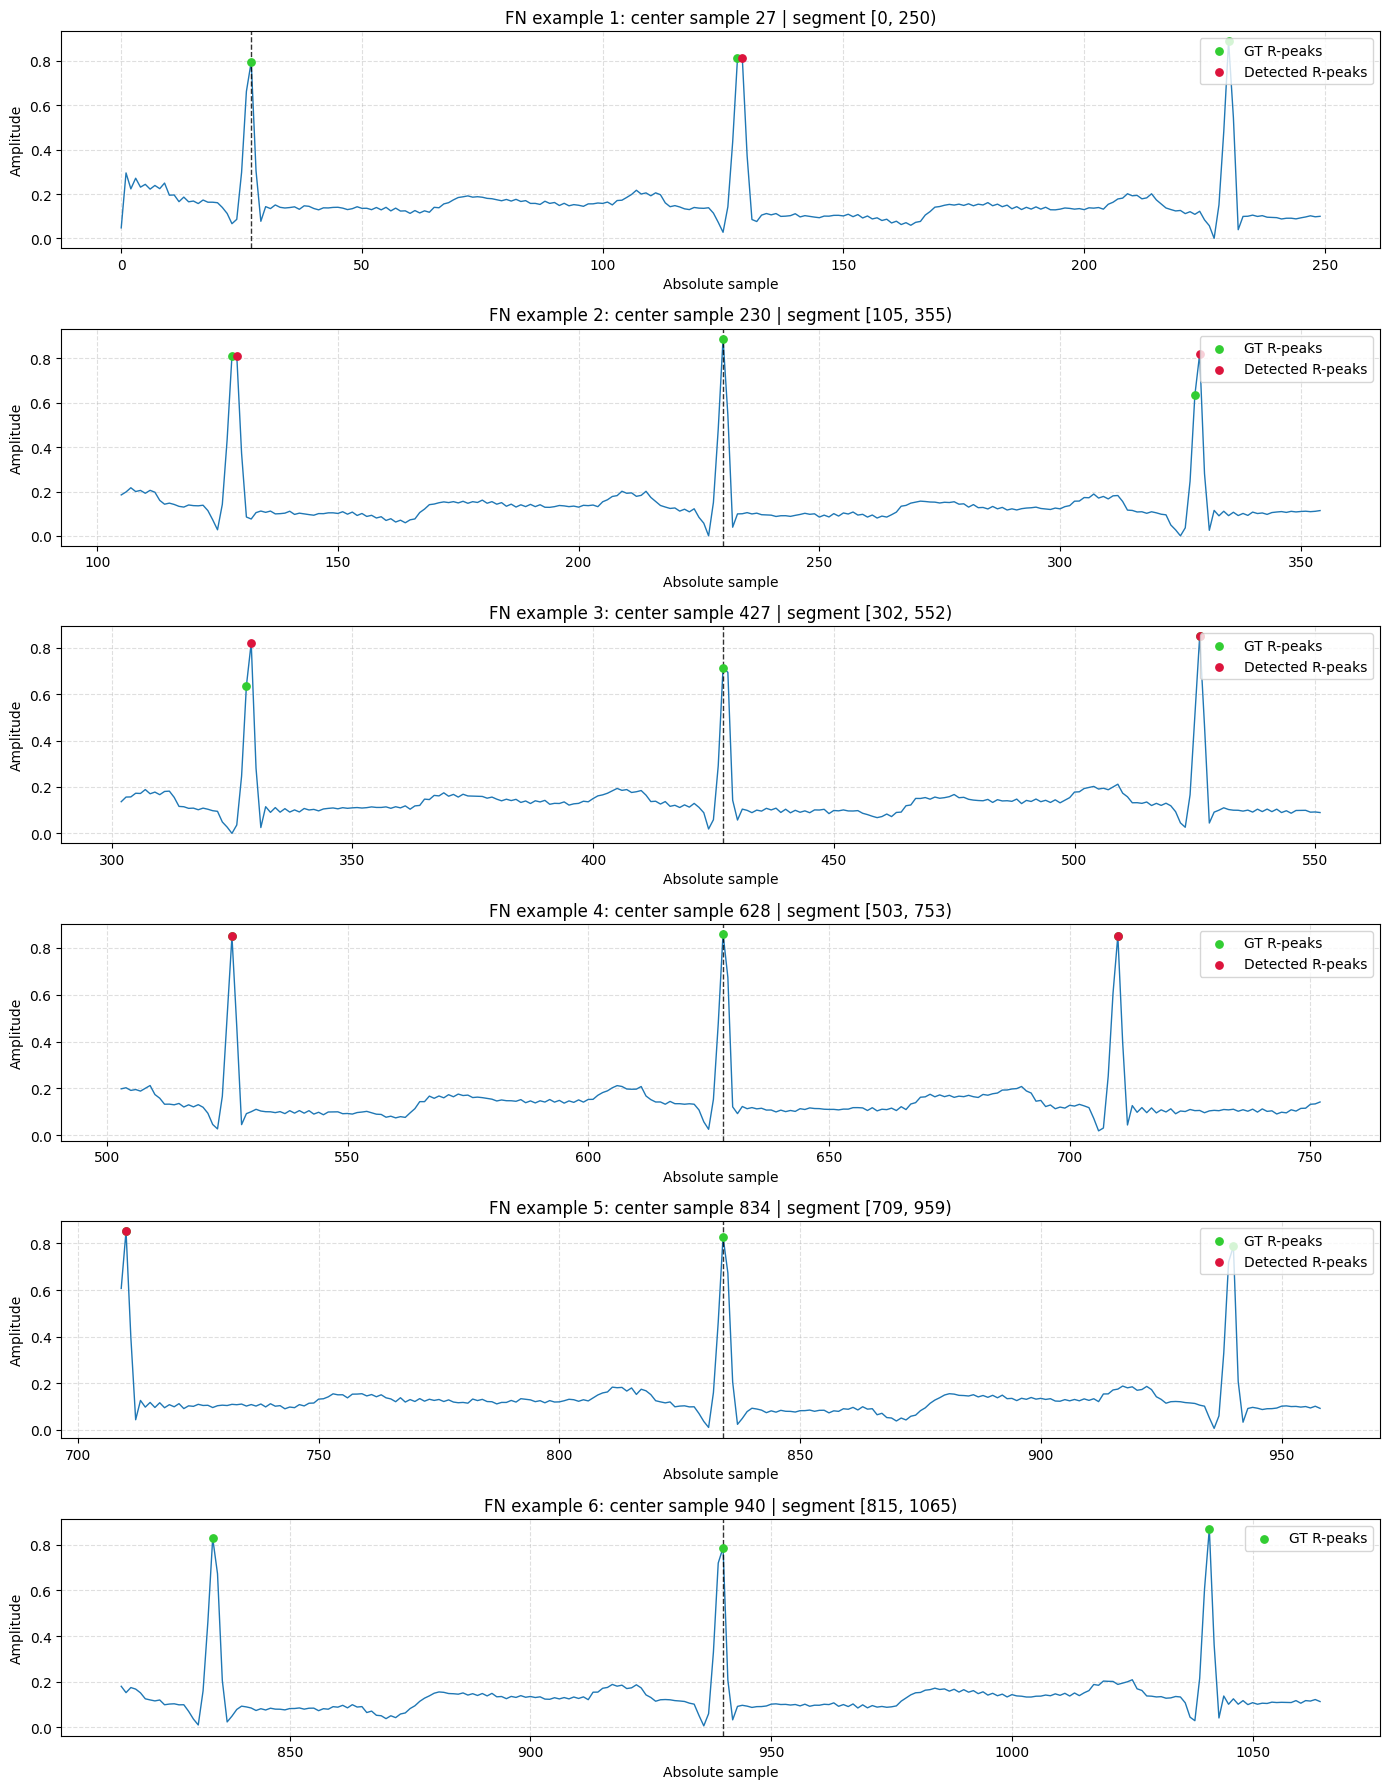

In [28]:
def plot_fp_fn_examples(events_df, signal_1d, gt_samples, fs=125, max_events=6, segment_sec=2.0):
    """
    Plot up to max_events examples of false positives and false negatives.

    Parameters
    ----------
    events_df : pd.DataFrame
        Output from evaluate_rpeak_detector_stream(...)
    signal_1d : array-like
        ECG signal used during evaluation (same indexing as gt_samples)
    gt_samples : array-like
        Ground-truth R-peak absolute sample indices
    fs : int
        Sampling rate in Hz
    max_events : int
        Maximum number of FP/FN examples to plot
    segment_sec : float
        Segment duration in seconds for each example (default 2 s)
    """
    signal_1d = np.asarray(signal_1d, dtype=np.float64)
    gt_samples = np.sort(np.asarray(gt_samples, dtype=int))

    if max_events <= 0:
        print("max_events <= 0, nothing to plot.")
        return

    segment_len = int(round(segment_sec * fs))
    segment_len = max(segment_len, 1)
    half_len = segment_len // 2

    # False positives: detected peak exists but event is not correct.
    fp_df = events_df[(events_df["detected_abs"].notna()) & (~events_df["is_correct"])].copy()
    fp_centers = fp_df["detected_abs"].astype(int).tolist()

    # False negatives: GT peaks that were never matched by any event.
    matched_gt = events_df["matched_gt"].dropna().astype(int).unique()
    matched_gt_set = set(matched_gt.tolist())
    fn_centers = [int(g) for g in gt_samples if int(g) not in matched_gt_set]

    # Select up to max_events total, roughly balanced FP/FN.
    n_fp = min(len(fp_centers), max_events // 2)
    n_fn = min(len(fn_centers), max_events - n_fp)

    # If one side has fewer examples, fill the remaining slots from the other side.
    remaining = max_events - (n_fp + n_fn)
    if remaining > 0:
        extra_fp = min(remaining, len(fp_centers) - n_fp)
        n_fp += extra_fp
        remaining -= extra_fp
    if remaining > 0:
        extra_fn = min(remaining, len(fn_centers) - n_fn)
        n_fn += extra_fn

    selected = ([('FP', c) for c in fp_centers[:n_fp]] + [('FN', c) for c in fn_centers[:n_fn]])

    if len(selected) == 0:
        print("No false positives or false negatives found for plotting.")
        return

    # All detected peaks (for overlay within each displayed segment)
    all_detected = events_df["detected_abs"].dropna().astype(int).to_numpy()

    fig, axes = plt.subplots(len(selected), 1, figsize=(14, 3 * len(selected)), squeeze=False)

    for i, (etype, center) in enumerate(selected):
        ax = axes[i, 0]

        start = max(0, center - half_len)
        end = min(len(signal_1d), start + segment_len)
        if end - start < segment_len:
            start = max(0, end - segment_len)

        seg = signal_1d[start:end]
        x = np.arange(start, end)

        ax.plot(x, seg, color="tab:blue", linewidth=1.0)

        # Overlay GT peaks in this segment
        gt_in_seg = gt_samples[(gt_samples >= start) & (gt_samples < end)]
        if len(gt_in_seg) > 0:
            ax.scatter(
                gt_in_seg,
                signal_1d[gt_in_seg],
                color="limegreen",
                s=28,
                zorder=3,
                label="GT R-peaks"
            )

        # Overlay detected peaks in this segment
        det_in_seg = all_detected[(all_detected >= start) & (all_detected < end)]
        if len(det_in_seg) > 0:
            ax.scatter(
                det_in_seg,
                signal_1d[det_in_seg],
                color="crimson",
                s=28,
                zorder=3,
                label="Detected R-peaks"
            )

        # Highlight the event center with a vertical dashed line
        ax.axvline(center, color="black", linestyle="--", linewidth=1.0, alpha=0.8)

        ax.set_title(f"{etype} example {i+1}: center sample {center} | segment [{start}, {end})")
        ax.set_xlabel("Absolute sample")
        ax.set_ylabel("Amplitude")
        ax.grid(True, linestyle="--", alpha=0.4)

        # Prevent duplicate legend entries.
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            ax.legend(unique.values(), unique.keys(), loc="upper right")

    plt.tight_layout()
    plt.show()


# Example usage (after events_df, x_eval, gt_eval exist):
plot_fp_fn_examples(
    events_df=events_df,
    signal_1d=x_eval,
    gt_samples=gt_eval,
    fs=target_fs,
    max_events=6,
    segment_sec=2.0,
)

## After the example analyzing the first record, we want to evaluate all records

[OK] 100: TP=263, FP=4279, FN=2010
[OK] 101: TP=1494, FP=2632, FN=379
[FAILED] 102: 125 Hz signal CSV not found for record '102' mode 'record_minmax': /content/mit-bih/signals/record_minmax/102_mlii_125hz_record.csv
[OK] 103: TP=1608, FP=2806, FN=482
[FAILED] 104: 125 Hz signal CSV not found for record '104' mode 'record_minmax': /content/mit-bih/signals/record_minmax/104_mlii_125hz_record.csv
[OK] 105: TP=998, FP=3661, FN=1692
[OK] 106: TP=1274, FP=3048, FN=783
[OK] 107: TP=749, FP=3352, FN=1390
[OK] 108: TP=1678, FP=2042, FN=145
[OK] 109: TP=2394, FP=1140, FN=140
[OK] 111: TP=601, FP=3664, FN=1531
[OK] 112: TP=1919, FP=3129, FN=630
[OK] 113: TP=998, FP=2652, FN=797
[OK] 114: TP=859, FP=3612, FN=1028
[OK] 115: TP=1555, FP=2573, FN=406
[OK] 116: TP=1823, FP=2810, FN=597
[OK] 117: TP=1487, FP=1654, FN=51
[OK] 118: TP=2265, FP=2454, FN=35
[OK] 119: TP=1669, FP=2069, FN=322
[OK] 121: TP=963, FP=2719, FN=912
[OK] 122: TP=294, FP=4623, FN=2184
[OK] 123: TP=1160, FP=2991, FN=358
[OK] 124: TP

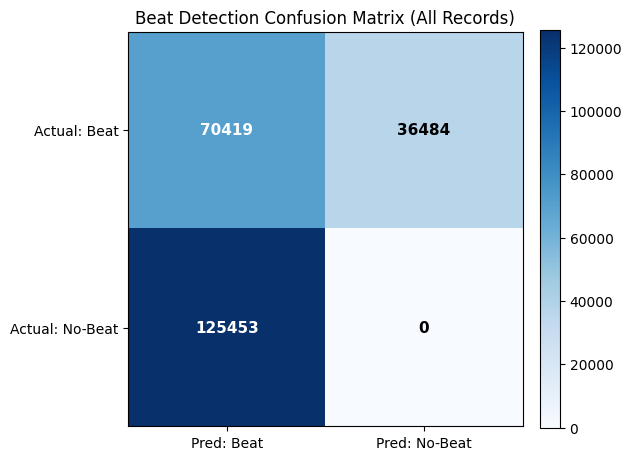


All-record evaluation summary:
records_total                                                                48
records_success                                                              46
records_failed                                                                2
tp_total                                                                  70419
fp_total                                                                 125453
fn_total                                                                  36484
micro_precision_ppv                                                    0.359515
micro_recall_sensitivity                                               0.658719
micro_f1                                                               0.465157
micro_detection_error_rate                                             1.514803
tolerance_ms                                                                150
signal_mode                                                       record_minmax
apply_ca

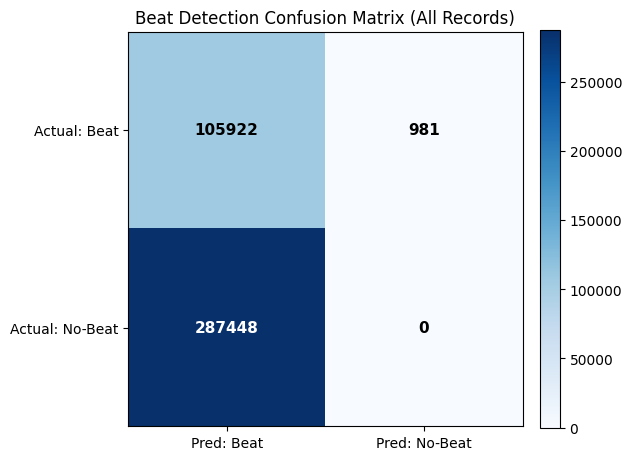


All-record evaluation summary:
records_total                                                                48
records_success                                                              46
records_failed                                                                2
tp_total                                                                 105922
fp_total                                                                 287448
fn_total                                                                    981
micro_precision_ppv                                                    0.269268
micro_recall_sensitivity                                               0.990823
micro_f1                                                               0.423457
micro_detection_error_rate                                             2.698044
tolerance_ms                                                                150
signal_mode                                                       record_minmax
apply_ca

,record_id,status,signal_csv,n_samples,n_gt_beats,tp,fp,fn,precision_ppv,recall_sensitivity,f1,detection_error_rate,windows_processed,apply_causal_filter,error_message
0,100,ok,/content/mit-bih/signals/record_minmax/100_mli...,225694.0,2273.0,2270.0,7724.0,3.0,0.227136,0.998680,0.370099,3.399472,9994.0,False,
1,101,ok,/content/mit-bih/signals/record_minmax/101_mli...,225694.0,1873.0,1866.0,9740.0,7.0,0.160779,0.996263,0.276875,5.203951,11607.0,False,
2,102,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '102' m...
3,103,ok,/content/mit-bih/signals/record_minmax/103_mli...,225694.0,2090.0,2084.0,5185.0,6.0,0.286697,0.997129,0.445347,2.483732,7269.0,False,
4,104,failed,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,125 Hz signal CSV not found for record '104' m...
5,105,ok,/content/mit-bih/signals/record_minmax/105_mli...,225694.0,2690.0,2643.0,10471.0,47.0,0.201540,0.982528,0.334472,3.910037,13115.0,False,
6,106,ok,/content/mit-bih/signals/record_minmax/106_mli...,225694.0,2057.0,2034.0,9271.0,23.0,0.179920,0.988819,0.304445,4.518230,11305.0,False,
7,107,ok,/content/mit-bih/signals/record_minmax/107_mli...,225694.0,2139.0,2133.0,7129.0,6.0,0.230296,0.997195,0.374178,3.335671,9262.0,False,
8,108,ok,/content/mit-bih/signals/record_minmax/108_mli...,225694.0,1823.0,1785.0,8184.0,38.0,0.179055,0.979155,0.302748,4.510148,9971.0,False,
9,109,ok,/content/mit-bih/signals/record_minmax/109_mli...,225694.0,2534.0,2525.0,5515.0,9.0,0.314055,0.996448,0.477587,2.179953,8040.0,False,


In [17]:
# Choose which precomputed 125 Hz signal set to evaluate:
#   - "online_robust"  #Uses a causal normalization (appropriate for online use)
#   - "record_minmax"  #It uses a per-record normalization (peeks into the future)
signal_mode_eval = "record_minmax"

# Toggle causal pre-filter before peak detector.
apply_causal_filter_eval = False
causal_filter_config_eval = {
    "lowcut": 0.5,
    "highcut": 40.0,
    "order": 2,
}


# === Added above since didn't run Cell 9

def plot_detection_confusion_matrix(tp, fp, fn, title="Beat Detection Confusion Matrix (All Records)"):
    """
    Plot an aggregate beat-detection confusion matrix.

    Matrix layout:
        rows   = actual    [Beat, No-Beat]
        cols   = predicted [Beat, No-Beat]

    Note: For event-level ECG beat detection, TN is typically not meaningful in this setup,
    so TN is set to 0 for a beat-centric summary view.
    """
    cm = np.array([[int(tp), int(fn)], [int(fp), 0]], dtype=np.int64)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Beat", "Pred: No-Beat"])
    ax.set_yticklabels(["Actual: Beat", "Actual: No-Beat"])
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            ax.text(
                j,
                i,
                f"{value}",
                ha="center",
                va="center",
                color="white" if value > cm.max() * 0.5 else "black",
                fontsize=11,
                fontweight="bold",
            )

    plt.tight_layout()
    plt.show()


def evaluate_all_records(
    local_dataset_dir,
    annotations_root,
    detector_fn,
    fs=125,
    signal_mode="record_minmax",
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=False,
    causal_filter_config=None,
    output_csv_path=None,
    plot_confusion=True,
    verbose=True,
):
    """
    Evaluate the detector across all local records and save per-record results.

    Returns
    -------
    results_df : pd.DataFrame
        Per-record metrics and metadata.
    overall_summary : dict
        Aggregated metrics across all successfully evaluated records.
    output_csv_path : str
        File path where results_df was saved.
    """
    record_ids = list_local_record_ids(local_dataset_dir)

    rows = []
    agg_tp, agg_fp, agg_fn = 0, 0, 0
    success_count, fail_count = 0, 0

    for rid in record_ids:
        try:
            record_id, x_125, gt_samples, ann_df, signal_csv_used = load_record_and_ground_truth(
                record_id=rid,
                annotations_root=annotations_root,
                signal_mode=signal_mode,
            )

            events_df_rec, summary_rec = evaluate_rpeak_detector_stream(
                signal_1d=x_125,
                gt_samples=gt_samples,
                detector_fn=detector_fn,
                fs=fs,
                window_sec=window_sec,
                tolerance_ms=tolerance_ms,
                apply_causal_filter=apply_causal_filter,
                causal_filter_config=causal_filter_config,
            )

            tp = int(summary_rec["tp"])
            fp = int(summary_rec["fp"])
            fn = int(summary_rec["fn"])

            agg_tp += tp
            agg_fp += fp
            agg_fn += fn
            success_count += 1

            rows.append({
                "record_id": record_id,
                "status": "ok",
                "signal_csv": signal_csv_used,
                "n_samples": int(len(x_125)),
                "n_gt_beats": int(len(gt_samples)),
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "precision_ppv": float(summary_rec["precision / ppv"]),
                "recall_sensitivity": float(summary_rec["recall / sensitivity"]),
                "f1": float(summary_rec["f1"]),
                "detection_error_rate": float(summary_rec["detection_error_rate"]),
                "windows_processed": int(summary_rec["windows_processed"]),
                "apply_causal_filter": bool(summary_rec["apply_causal_filter"]),
                "error_message": "",
            })

            if verbose:
                print(f"[OK] {record_id}: TP={tp}, FP={fp}, FN={fn}")

        except Exception as exc:
            fail_count += 1
            rows.append({
                "record_id": str(rid),
                "status": "failed",
                "signal_csv": "",
                "n_samples": np.nan,
                "n_gt_beats": np.nan,
                "tp": np.nan,
                "fp": np.nan,
                "fn": np.nan,
                "precision_ppv": np.nan,
                "recall_sensitivity": np.nan,
                "f1": np.nan,
                "detection_error_rate": np.nan,
                "windows_processed": np.nan,
                "apply_causal_filter": bool(apply_causal_filter),
                "error_message": str(exc),
            })

            if verbose:
                print(f"[FAILED] {rid}: {exc}")

    results_df = pd.DataFrame(rows)

    if output_csv_path is None:
        output_csv_path = os.path.join(annotations_root, "evaluation", "all_records_results.csv")
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
    results_df.to_csv(output_csv_path, index=False)

    micro_precision = agg_tp / (agg_tp + agg_fp) if (agg_tp + agg_fp) > 0 else 0.0
    micro_recall = agg_tp / (agg_tp + agg_fn) if (agg_tp + agg_fn) > 0 else 0.0
    micro_f1 = (2 * micro_precision * micro_recall / (micro_precision + micro_recall)) if (micro_precision + micro_recall) > 0 else 0.0
    micro_der = (agg_fp + agg_fn) / (agg_tp + agg_fn) if (agg_tp + agg_fn) > 0 else 0.0

    overall_summary = {
        "records_total": int(len(record_ids)),
        "records_success": int(success_count),
        "records_failed": int(fail_count),
        "tp_total": int(agg_tp),
        "fp_total": int(agg_fp),
        "fn_total": int(agg_fn),
        "micro_precision_ppv": float(micro_precision),
        "micro_recall_sensitivity": float(micro_recall),
        "micro_f1": float(micro_f1),
        "micro_detection_error_rate": float(micro_der),
        "tolerance_ms": int(tolerance_ms),
        "signal_mode": str(signal_mode),
        "apply_causal_filter": bool(apply_causal_filter),
        "output_csv": output_csv_path,
    }

    if plot_confusion and (agg_tp + agg_fp + agg_fn) > 0:
        plot_detection_confusion_matrix(
            tp=agg_tp,
            fp=agg_fp,
            fn=agg_fn,
            title="Beat Detection Confusion Matrix (All Records)",
        )

    if verbose:
        print("\nAll-record evaluation summary:")
        print(pd.Series(overall_summary))
        print(f"\nSaved per-record results to: {output_csv_path}")

    return results_df, overall_summary, output_csv_path


## -------- Example run: evaluate ALL records --------
# all_results_df, all_summary, all_results_csv = evaluate_all_records(
#     local_dataset_dir=mit_bih_path,
#     annotations_root=annotations_path,
#     detector_fn=peak_detector,
#     fs=target_fs,
#     signal_mode=signal_mode_eval,
#     window_sec=2,
#     tolerance_ms=150,
#     apply_causal_filter=apply_causal_filter_eval,
#     causal_filter_config=causal_filter_config_eval,
#     output_csv_path=None,  # defaults to: <annotations_root>/evaluation/all_records_results.csv
#     plot_confusion=True,
#     verbose=True,

# )


all_results_df_sma, all_summary_sma, all_results_csv_sma = evaluate_all_records(
    local_dataset_dir=mit_bih_path,
    annotations_root=annotations_path,
    detector_fn=sma_detector,
    fs=target_fs,
    signal_mode=signal_mode_eval,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=apply_causal_filter_eval,
    causal_filter_config=causal_filter_config_eval,
    output_csv_path=r"/content/mit-bih/evaluation/all_records_results_sma.csv",  # defaults to: <annotations_root>/evaluation/all_records_results.csv
    plot_confusion=True,
    verbose=True,
)
all_results_df_sma.head(10)

all_results_df_hc, all_summary_hc, all_results_csv_hc = evaluate_all_records(
    local_dataset_dir=mit_bih_path,
    annotations_root=annotations_path,
    detector_fn=hc_detector,
    fs=target_fs,
    signal_mode=signal_mode_eval,
    window_sec=2,
    tolerance_ms=150,
    apply_causal_filter=apply_causal_filter_eval,
    causal_filter_config=causal_filter_config_eval,
    output_csv_path=r"/content/mit-bih/evaluation/all_records_results_hc.csv",  # defaults to: <annotations_root>/evaluation/all_records_results.csv
    plot_confusion=True,
    verbose=True,
)
all_results_df_hc.head(10)

In [ ]:
# Diagnostics: GT accounting and duplicate detection checks

# 1) Single-record checks from current events_df / gt_eval
detected_series = events_df["detected_abs"].dropna().astype(int)
matched_series = events_df["matched_gt"].dropna().astype(int)

single_record_diag = {
    "record_id": record_id_eval,
    "gt_count": int(len(gt_eval)),
    "detected_count": int(len(detected_series)),
    "detected_unique_count": int(detected_series.nunique()),
    "detected_repeats": int(len(detected_series) - detected_series.nunique()),
    "matched_gt_count": int(len(matched_series)),
    "matched_gt_unique_count": int(matched_series.nunique()),
    "matched_gt_repeats": int(len(matched_series) - matched_series.nunique()),
    "tp_plus_fn_equals_gt": int(summary["tp"] + summary["fn"]) == int(len(gt_eval)),
}

print("Single-record diagnostic:")
print(pd.Series(single_record_diag))

# 2) All-record checks from all_results_df (successful rows only)
ok_df = all_results_df[all_results_df["status"] == "ok"].copy()

gt_total_ok = int(ok_df["n_gt_beats"].sum())
tp_total_ok = int(ok_df["tp"].sum())
fn_total_ok = int(ok_df["fn"].sum())

all_records_diag = {
    "records_ok": int(len(ok_df)),
    "gt_total_ok": gt_total_ok,
    "tp_total_ok": tp_total_ok,
    "fn_total_ok": fn_total_ok,
    "tp_plus_fn_equals_gt_total": (tp_total_ok + fn_total_ok) == gt_total_ok,
}

print("\nAll-record diagnostic:")
print(pd.Series(all_records_diag))

# Show any per-record accounting mismatches (should be none).
mismatch_df = ok_df[(ok_df["tp"] + ok_df["fn"]) != ok_df["n_gt_beats"]]
print("\nPer-record accounting mismatches (tp + fn != n_gt_beats):")
print(mismatch_df[["record_id", "n_gt_beats", "tp", "fn"]].head(20))

Single-record diagnostic:
record_id                   100
gt_count                   2273
detected_count             2269
detected_unique_count      2269
detected_repeats              0
matched_gt_count           2269
matched_gt_unique_count    2269
matched_gt_repeats            0
tp_plus_fn_equals_gt       True
dtype: object

All-record diagnostic:
records_ok                        46
gt_total_ok                   106903
tp_total_ok                    44826
fn_total_ok                    62077
tp_plus_fn_equals_gt_total      True
dtype: object

Per-record accounting mismatches (tp + fn != n_gt_beats):
Empty DataFrame
Columns: [record_id, n_gt_beats, tp, fn]
Index: []


In [ ]:
# Side-by-side benchmark: NeuroKit2 vs Pan-Tompkins

benchmark_detectors = [
    ("neurokit", peak_detector),
    ("pan_tompkins", pan_tompkins_peak_detector),
]

benchmark_rows = []
benchmark_outputs = {}

record_ids_local = list_local_record_ids(mit_bih_path)
record_id_bench = record_ids_local[0]

for detector_name, detector_fn_bench in benchmark_detectors:
    print(f"\n===== Benchmarking detector: {detector_name} =====")

    # --- First-record evaluation ---
    record_id_eval_b, x_eval_b, gt_eval_b, ann_eval_b, signal_csv_b = load_record_and_ground_truth(
        record_id=record_id_bench,
        annotations_root=annotations_path,
        signal_mode=signal_mode_eval,
    )

    events_df_b, summary_b = evaluate_rpeak_detector_stream(
        signal_1d=x_eval_b,
        gt_samples=gt_eval_b,
        detector_fn=detector_fn_bench,
        fs=target_fs,
        window_sec=2,
        tolerance_ms=150,
        apply_causal_filter=apply_causal_filter_eval,
        causal_filter_config=causal_filter_config_eval,
        anchor_offset_samples=20,
    )

    # --- All-record evaluation with detector-specific output CSV ---
    output_csv_b = os.path.join(
        annotations_path,
        "evaluation",
        f"all_records_results_{detector_name}.csv",
    )

    all_results_df_b, all_summary_b, all_results_csv_b = evaluate_all_records(
        local_dataset_dir=mit_bih_path,
        annotations_root=annotations_path,
        detector_fn=detector_fn_bench,
        fs=target_fs,
        signal_mode=signal_mode_eval,
        window_sec=2,
        tolerance_ms=150,
        apply_causal_filter=apply_causal_filter_eval,
        causal_filter_config=causal_filter_config_eval,
        output_csv_path=output_csv_b,
        plot_confusion=False,
        verbose=False,
    )

    benchmark_outputs[detector_name] = {
        "first_record_events": events_df_b,
        "first_record_summary": summary_b,
        "all_results_df": all_results_df_b,
        "all_summary": all_summary_b,
        "all_results_csv": all_results_csv_b,
    }

    benchmark_rows.append({
        "detector": detector_name,
        "first_record_id": record_id_eval_b,
        "first_record_tp": int(summary_b["tp"]),
        "first_record_fp": int(summary_b["fp"]),
        "first_record_fn": int(summary_b["fn"]),
        "first_record_f1": float(summary_b["f1"]),
        "all_records_success": int(all_summary_b["records_success"]),
        "all_records_failed": int(all_summary_b["records_failed"]),
        "all_tp_total": int(all_summary_b["tp_total"]),
        "all_fp_total": int(all_summary_b["fp_total"]),
        "all_fn_total": int(all_summary_b["fn_total"]),
        "all_micro_precision": float(all_summary_b["micro_precision_ppv"]),
        "all_micro_recall": float(all_summary_b["micro_recall_sensitivity"]),
        "all_micro_f1": float(all_summary_b["micro_f1"]),
        "all_micro_der": float(all_summary_b["micro_detection_error_rate"]),
        "csv_path": all_results_csv_b,
    })

benchmark_compare_df = pd.DataFrame(benchmark_rows)
print("\n=== Benchmark comparison (first record + all records) ===")
display(benchmark_compare_df)

print("\nSaved detector-specific CSV files:")
for _, row in benchmark_compare_df.iterrows():
    print(f"- {row['detector']}: {row['csv_path']}")


===== Benchmarking detector: neurokit =====


c:\Users\Antonio\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
c:\Users\Antonio\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
c:\Users\Antonio\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
c:\Users\Antonio\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide



===== Benchmarking detector: pan_tompkins =====

=== Benchmark comparison (first record + all records) ===


,detector,first_record_id,first_record_tp,first_record_fp,first_record_fn,first_record_f1,all_records_success,all_records_failed,all_tp_total,all_fp_total,all_fn_total,all_micro_precision,all_micro_recall,all_micro_f1,all_micro_der,csv_path
0,neurokit,100,1128,0,1145,0.663334,46,2,44826,771,62077,0.983091,0.419315,0.587882,0.587897,C:\repos\ecg-dataset-single-lead\mit-bih\evalu...
1,pan_tompkins,100,2269,0,4,0.999119,46,2,101438,88,5465,0.999133,0.948879,0.973358,0.051944,C:\repos\ecg-dataset-single-lead\mit-bih\evalu...



Saved detector-specific CSV files:
- neurokit: C:\repos\ecg-dataset-single-lead\mit-bih\evaluation\all_records_results_neurokit.csv
- pan_tompkins: C:\repos\ecg-dataset-single-lead\mit-bih\evaluation\all_records_results_pan_tompkins.csv
